# Chains and cosmological constraints — `output/v1.txt`

Loads the CosmoSIS `emcee` chain produced by the HMF+MOR forecast pipeline,
inspects walker traces for burn-in/mixing, and makes a triangle (contour)
plot of the cosmological parameter constraints (`omega_m`, `sigma8_input`).

In [1]:
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from getdist import MCSamples, plots

# must come after importing getdist.plots, which resets the mpl backend
%matplotlib inline

CHAIN_FILE = Path("../output/v1.txt")

## Load chain + header metadata

In [2]:
def read_cosmosis_chain(path):
    """Parse a CosmoSIS text-sampler output file.

    Returns the data array, the column names, and a dict of the
    `#key=value` header metadata (sampler, walkers, nsteps, etc).
    """
    columns = None
    meta = {}
    with open(path) as f:
        for line in f:
            if not line.startswith("#"):
                break
            if line.startswith("## "):
                continue
            header = line[1:].strip()
            if columns is None:
                columns = header.split()
                continue
            if "=" in header:
                key, _, val = header.partition("=")
                meta[key.strip()] = val.strip()

    data = np.loadtxt(path)
    return data, columns, meta


data, columns, meta = read_cosmosis_chain(CHAIN_FILE)
nwalkers = int(meta["walkers"])
nsteps = data.shape[0] // nwalkers

print(f"columns: {columns}")
sampler_name = meta.get("sampler")
print(f"sampler={sampler_name}  walkers={nwalkers}  steps={nsteps}  rows={data.shape[0]}")

columns: ['cosmological_parameters--omega_m', 'cosmological_parameters--sigma8_input', 'prior', 'post']
sampler=emcee  walkers=20  steps=100  rows=2000


## Reshape into (walker, step, param)

CosmoSIS's `emcee` sampler writes rows step-major: all walkers for step 0,
then all walkers for step 1, etc.

In [3]:
param_names = [c for c in columns if c not in ("prior", "post")]
param_idx = [columns.index(p) for p in param_names]

chain = data.reshape(nsteps, nwalkers, len(columns)).transpose(1, 0, 2)
log_post = chain[:, :, columns.index("post")]

print(f"parameters: {param_names}")
print(f"chain shape (walkers, steps, cols): {chain.shape}")

parameters: ['cosmological_parameters--omega_m', 'cosmological_parameters--sigma8_input']
chain shape (walkers, steps, cols): (20, 100, 4)


## Walker traces

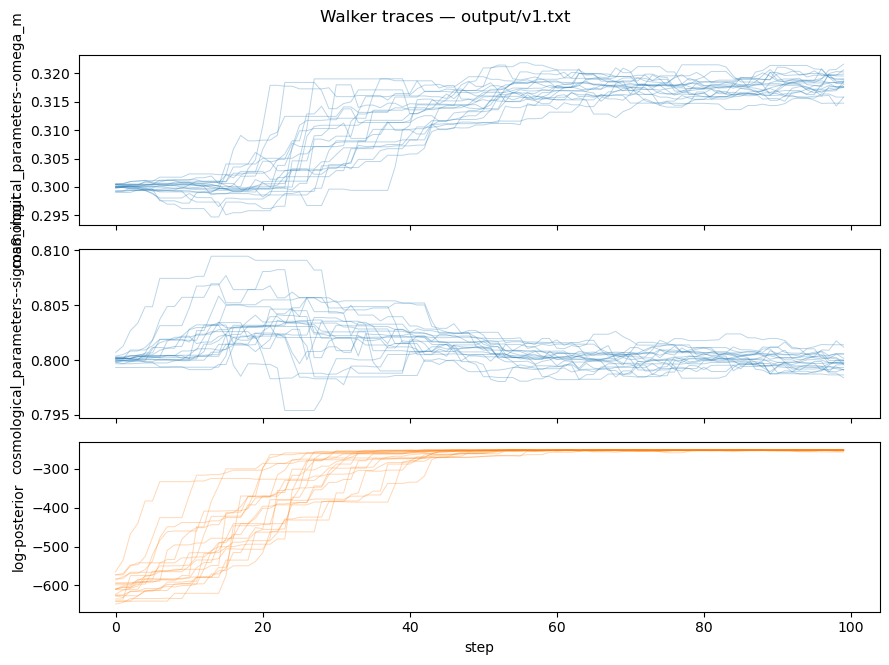

In [4]:
fig, axes = plt.subplots(len(param_names) + 1, 1, figsize=(9, 2.2 * (len(param_names) + 1)), sharex=True)

for i, name in enumerate(param_names):
    ax = axes[i]
    for w in range(nwalkers):
        ax.plot(chain[w, :, param_idx[i]], color="C0", alpha=0.3, lw=0.7)
    ax.set_ylabel(name)

ax = axes[-1]
for w in range(nwalkers):
    ax.plot(log_post[w], color="C1", alpha=0.3, lw=0.7)
ax.set_ylabel("log-posterior")
ax.set_xlabel("step")

fig.suptitle("Walker traces — output/v1.txt", y=1.0)
fig.tight_layout()
plt.show()

## Burn-in cut

Adjust `burnin_frac` after looking at the traces above — the walkers should
look like a stationary "fuzzy caterpillar" past the burn-in point.

In [5]:
burnin_frac = 0.3
burnin_steps = int(burnin_frac * nsteps)

flat_samples = chain[:, burnin_steps:, :].reshape(-1, len(columns))
flat_params = flat_samples[:, param_idx]
flat_post = flat_samples[:, columns.index("post")]

print(f"discarding first {burnin_steps}/{nsteps} steps as burn-in")
print(f"flattened samples: {flat_params.shape[0]}")

discarding first 30/100 steps as burn-in
flattened samples: 1400


## Triangle plot of cosmological constraints

Removed no burn in


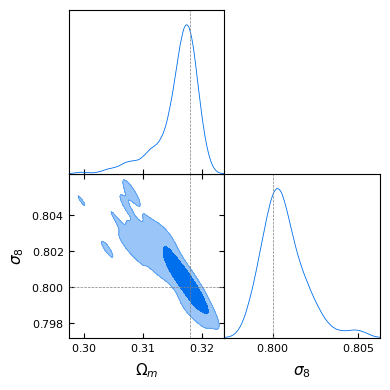

In [6]:
labels = {
    "cosmological_parameters--omega_m": r"\Omega_m",
    "cosmological_parameters--sigma8_input": r"\sigma_8",
}
param_labels = [labels.get(p, p) for p in param_names]

samples = MCSamples(
    samples=flat_params,
    names=param_names,
    labels=param_labels,
    label="v1",
)

# fiducial values used to generate the mock data (see mass_function_like config)
fiducial = {
    "cosmological_parameters--omega_m": 0.318,
    "cosmological_parameters--sigma8_input": 0.80,
}
markers = {p: fiducial[p] for p in param_names if p in fiducial}

g = plots.get_subplot_plotter()
g.triangle_plot(samples, param_names, filled=True, markers=markers)
plt.show()

## 1D marginalized constraints

In [7]:
for p, lbl in zip(param_names, param_labels):
    stats = samples.getMargeStats().parWithName(p)
    print(f"{lbl:>10s} = {stats.mean:.4f} +/- {stats.err:.4f}")

  \Omega_m = 0.3159 +/- 0.0037
  \sigma_8 = 0.8006 +/- 0.0014
